In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Thiết bị đang dùng:", device)

Thiết bị đang dùng: cuda


Import thư viện cần dùng

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

Khai báo cấu hình ban đầu

In [ ]:
BATCH_SIZE = 64
EPOCHS = 15
LEARNING_RATE = 0.001
PATIENCE = 3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Tải và tiền xử lý dữ liệu MNIST

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_full = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.57MB/s]


Chia tập train và validation

In [ ]:
train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size

train_dataset, val_dataset = random_split(train_full, [train_size, val_size])

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 48000
Validation size: 12000
Test size: 10000


Tạo DataLoader

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Hiển thị thử ảnh MNIST

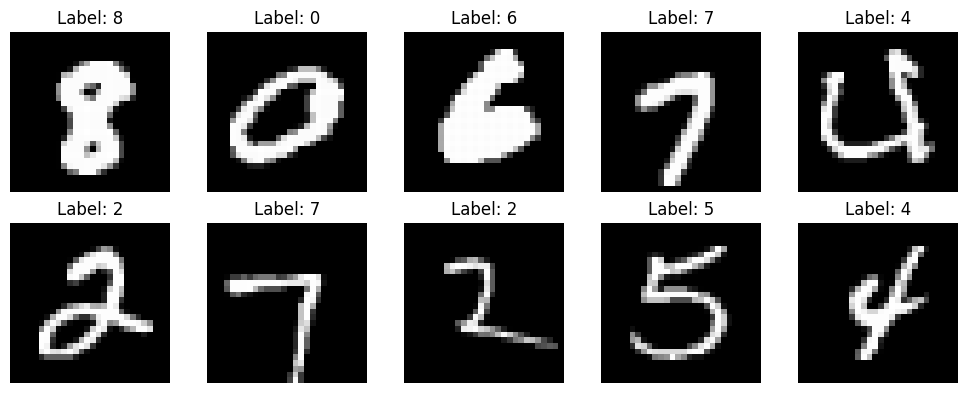

In [ ]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Xây dựng mô hình VGG-style CNN bằng PyTorch

In [ ]:
class VGGStyleCNN(nn.Module):
    def __init__(self):
        super(VGGStyleCNN, self).__init__()

        # Input: (batch_size, 1, 28, 28)
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),   # 28x28 -> 14x14
            nn.Dropout(0.25),

            # Block 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),   # 14x14 -> 7x7
            nn.Dropout(0.25)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)  # Output logits cho 10 lớp chữ số 0-9
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = VGGStyleCNN().to(device)
print(model)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Số tham số trainable:", count_parameters(model))

VGGStyleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Dropout(p=0.25, inplace=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
Số tham số trainable: 467818


Khai báo Loss Function và Optimizer

In [ ]:
# Trong PyTorch, CrossEntropyLoss đã bao gồm Softmax bên trong.
# Vì vậy output cuối của model là logits, không cần dùng Softmax trong forward.
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Viết hàm train một epoch

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

Viết hàm đánh giá validation/test

In [ ]:
def evaluate(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels

Train mô hình

In [ ]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_loss = float("inf")
patience_counter = 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, _, _ = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_vgg_mnist_pytorch.pth")
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print("Early stopping!")
        break

Epoch [1/15] Train Loss: 0.2537, Train Acc: 0.9213 | Val Loss: 0.0625, Val Acc: 0.9807
Epoch [2/15] Train Loss: 0.0933, Train Acc: 0.9729 | Val Loss: 0.0403, Val Acc: 0.9871
Epoch [3/15] Train Loss: 0.0694, Train Acc: 0.9794 | Val Loss: 0.0400, Val Acc: 0.9878
Epoch [4/15] Train Loss: 0.0587, Train Acc: 0.9835 | Val Loss: 0.0363, Val Acc: 0.9886
Epoch [5/15] Train Loss: 0.0506, Train Acc: 0.9853 | Val Loss: 0.0371, Val Acc: 0.9895
Epoch [6/15] Train Loss: 0.0462, Train Acc: 0.9859 | Val Loss: 0.0364, Val Acc: 0.9893
Epoch [7/15] Train Loss: 0.0404, Train Acc: 0.9881 | Val Loss: 0.0262, Val Acc: 0.9925
Epoch [8/15] Train Loss: 0.0375, Train Acc: 0.9884 | Val Loss: 0.0270, Val Acc: 0.9928
Epoch [9/15] Train Loss: 0.0350, Train Acc: 0.9900 | Val Loss: 0.0288, Val Acc: 0.9922
Epoch [10/15] Train Loss: 0.0349, Train Acc: 0.9895 | Val Loss: 0.0342, Val Acc: 0.9902
Early stopping!


Vẽ biểu đồ Loss và Accuracy

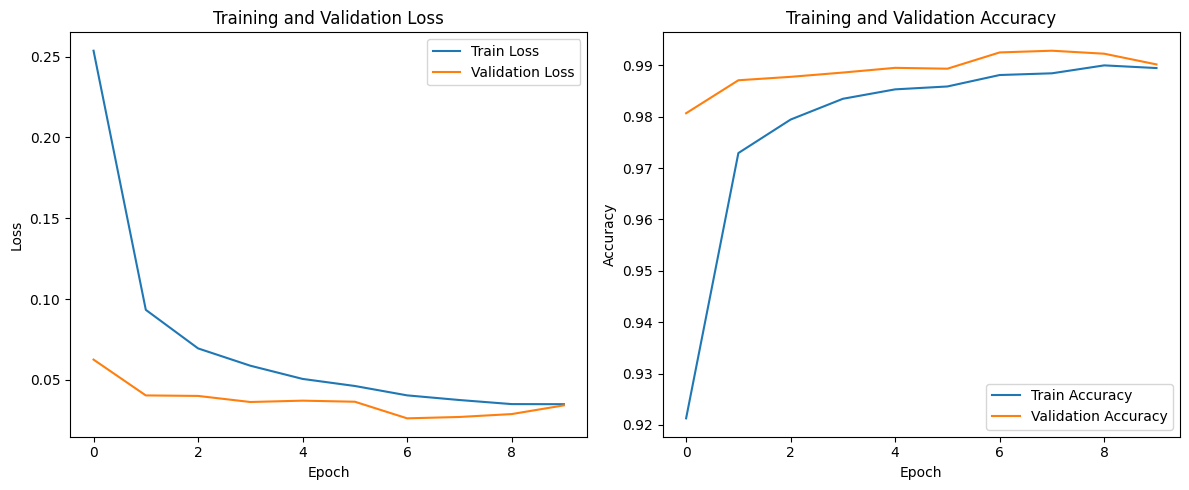

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

Đánh giá trên tập test

In [ ]:
model.load_state_dict(torch.load("best_vgg_mnist_pytorch.pth"))

test_loss, test_acc, test_preds, test_labels = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

Test Loss: 0.02123083369228043
Test Accuracy: 0.9933


Vẽ Confusion Matrix

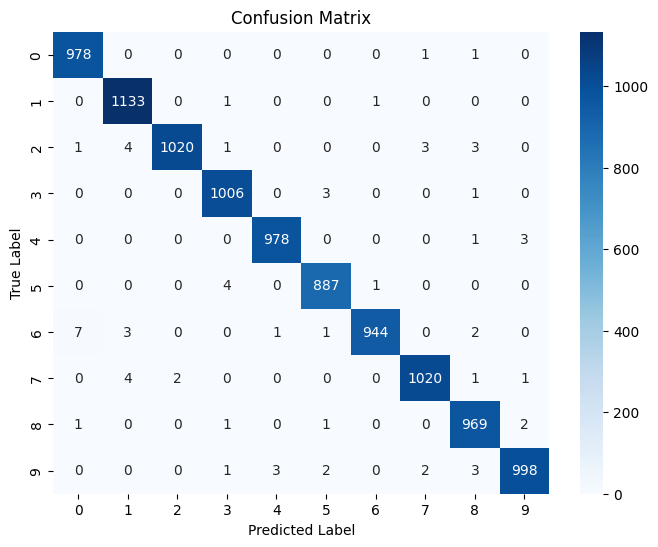

In [ ]:
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(range(10)),
    yticklabels=list(range(10))
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In Classification Report

In [ ]:
print(classification_report(test_labels, test_preds))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       1.00      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       1.00      1.00      1.00       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



Hiển thị ảnh dự đoán đúng và sai

In [ ]:
model.eval()

correct_images = []
wrong_images = []

with torch.no_grad():
    for images, labels in test_loader:
        images_device = images.to(device)
        labels_device = labels.to(device)

        outputs = model(images_device)
        _, predicted = torch.max(outputs, 1)

        for i in range(len(labels)):
            img = images[i].squeeze().numpy()
            true_label = labels[i].item()
            pred_label = predicted[i].cpu().item()

            if true_label == pred_label and len(correct_images) < 5:
                correct_images.append((img, true_label, pred_label))

            if true_label != pred_label and len(wrong_images) < 5:
                wrong_images.append((img, true_label, pred_label))

        if len(correct_images) >= 5 and len(wrong_images) >= 5:
            break

Hiển thị ảnh đúng:

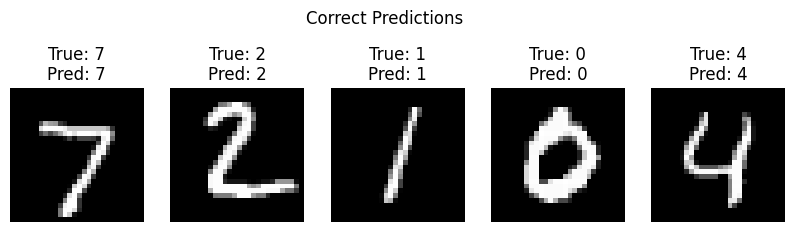

In [ ]:
plt.figure(figsize=(10, 3))

for i, (img, true_label, pred_label) in enumerate(correct_images):
    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.suptitle("Correct Predictions")
plt.show()

Hiển thị ảnh sai:

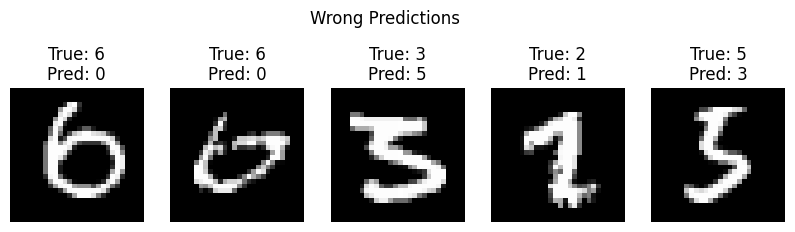

In [ ]:
plt.figure(figsize=(10, 3))

for i, (img, true_label, pred_label) in enumerate(wrong_images):
    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.suptitle("Wrong Predictions")
plt.show()

In [ ]:
# ================================
# LƯU MODEL CUỐI CÙNG VÀ IN THÔNG TIN
# ================================

final_model_path = "VGG_MNIST_PyTorch_final.pt"

# Lưu trọng số model cuối cùng
torch.save(model.state_dict(), final_model_path)

print("=============== THÔNG TIN LƯU MODEL ===============")
print(f" Tên file        : {final_model_path}")
print(f" Định dạng       : PyTorch state_dict (.pt)")
print(f" Val Loss tốt    : {best_val_loss:.4f}")
print(f" Test Accuracy   : {test_acc * 100:.2f}%")
print(f" Mô hình         : VGG-style CNN")
print(f" Framework       : PyTorch")
print(f" Dùng cho demo   : Dự đoán chữ số viết tay MNIST")

=============== THÔNG TIN LƯU MODEL ===============
 Tên file        : VGG_MNIST_PyTorch_final.pt
 Định dạng       : PyTorch state_dict (.pt)
 Val Loss tốt    : 0.0262
 Test Accuracy   : 99.33%
 Mô hình         : VGG-style CNN
 Framework       : PyTorch
 Dùng cho demo   : Dự đoán chữ số viết tay MNIST


In [ ]:
import os, glob

print("Thư mục hiện tại:", os.getcwd())

print("Các file .pth:")
print(glob.glob("*.pth"))

print("Các file .pt:")
print(glob.glob("*.pt"))

print("Có best_vgg_mnist_pytorch.pth không?")
print(os.path.exists("best_vgg_mnist_pytorch.pth"))

Thư mục hiện tại: /content
Các file .pth:
['best_vgg_mnist_pytorch.pth']
Các file .pt:
['VGG_MNIST_PyTorch_final.pt']
Có best_vgg_mnist_pytorch.pth không?
True


In [ ]:
from google.colab import files

files.download("best_vgg_mnist_pytorch.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model_code = '''
import torch
import torch.nn as nn

class VGGStyleCNN(nn.Module):
    def __init__(self):
        super(VGGStyleCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),

            # Block 2
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
'''

with open("VGGStyleCNN_model.py", "w", encoding="utf-8") as f:
    f.write(model_code)

print("Đã tạo file VGGStyleCNN_model.py")

Đã tạo file VGGStyleCNN_model.py


In [ ]:
import os, glob

print(glob.glob("*.py"))
print(os.path.exists("VGGStyleCNN_model.py"))

['VGGStyleCNN_model.py']
True


In [ ]:
import torch
from VGGStyleCNN_model import VGGStyleCNN

model = VGGStyleCNN()

state_dict = torch.load(
    "best_vgg_mnist_pytorch.pth",
    map_location="cpu"
)

model.load_state_dict(state_dict)
model.eval()

print("Load VGG best model thành công!")

Load VGG best model thành công!


In [ ]:
from google.colab import files

files.download("VGGStyleCNN_model.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>